# Week 7 — Advanced Models

This notebook:

1. **Recomputes the full metric suite** (R², MAE, MAPE, MdAPE) for the baseline/engineered models
   from `04_testing_models.ipynb` and `05_feature_engineering.ipynb`, on **both train and test**,
   across all three feature sets built so far: `old_feature_cols` (pre-Week-6 baseline),
   `new_feature_cols` (Week 6: + BedBathRatio, PropertyAge, SchoolDistrict_MeanPrice), and
   `newest_feature_cols` / "v2" (+ CloseMonth sin/cos, DistanceToNearestCBD_km). Week 6 only
   reported test-set R²/MAE/MAPE for the first two feature sets — this fills in the train side
   (to check over/underfit gaps) and MdAPE (the headline metric per the AVM best-practices doc),
   and brings v2 into the same comparison for the first time.
2. Trains **XGBoost** and **LightGBM** on the best-performing feature set from step 1, with light
   hyperparameter tuning over `max_depth`, `learning_rate`, and `n_estimators`, using a validation
   month carved out of train (never touching test until the final evaluation). Also re-tunes
   **Decision Tree** and **Random Forest** the same way — their step-1 configs
   (`max_depth=10`/`15`, `n_estimators=100`) were arbitrary, not the result of a search — over
   `max_depth`/`min_samples_leaf` (tree) and `n_estimators`/`max_depth`/`min_samples_leaf` (forest).
3. Compares baseline vs. advanced side by side and proposes next models to try.


In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
 

## MdAPE Helper

sklearn ships `mean_absolute_percentage_error` but no median version. Per the best-practices doc,
MdAPE (median absolute percentage error) is the headline metric — real-estate errors are
right-skewed and multi-scale, so a few badly-mispriced luxury homes shouldn't dominate the summary
number the way they do with a mean-based metric. Defined once here and reused everywhere below.

In [2]:
def median_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.median(np.abs((y_true - y_pred) / y_true))


## Load Data

Three feature-set / file pairs, all built in `05_feature_engineering.ipynb` and all sharing the
same chronological split (train = 2023-06 through 2025-05, test = 2025-06, touched once at the
end of this notebook):

- `basic_train_set.csv` / `basic_test_set.csv` — `old_feature_cols`, the pre-Week-6 baseline.
- `engineered_train_set.csv` / `engineered_test_set.csv` — `new_feature_cols`
  (old + BedBathRatio, PropertyAge, SchoolDistrict_MeanPrice).
- `engineered_train_set_v2.csv` / `engineered_test_set_v2.csv` — `newest_feature_cols`
  (new + CloseMonth_sin, CloseMonth_cos, DistanceToNearestCBD_km).

Feature-column lists are recreated here to match `05_feature_engineering.ipynb` exactly, rather
than re-running the school-district spatial join / CBD-distance pipeline.

In [3]:
basic_train = pd.read_csv("basic_train_set.csv")
basic_test = pd.read_csv("basic_test_set.csv")

eng_train = pd.read_csv("engineered_train_set.csv")
eng_test = pd.read_csv("engineered_test_set.csv")

eng_train_v2 = pd.read_csv("engineered_train_set_v2.csv")
eng_test_v2 = pd.read_csv("engineered_test_set_v2.csv")

old_feature_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
                     'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms',
                     'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels']

new_feature_cols = old_feature_cols + ['BedBathRatio', 'PropertyAge', 'SchoolDistrict_MeanPrice']

newest_feature_cols = new_feature_cols + ['CloseMonth_sin', 'CloseMonth_cos', 'DistanceToNearestCBD_km']

print(f"old  ({len(old_feature_cols)} features): {basic_train.shape}, {basic_test.shape}")
print(f"new  ({len(new_feature_cols)} features): {eng_train.shape}, {eng_test.shape}")
print(f"v2   ({len(newest_feature_cols)} features): {eng_train_v2.shape}, {eng_test_v2.shape}")


/tmp/ipykernel_73890/2767572847.py:1: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  basic_train = pd.read_csv("basic_train_set.csv")
/tmp/ipykernel_73890/2767572847.py:4: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  eng_train = pd.read_csv("engineered_train_set.csv")
/tmp/ipykernel_73890/2767572847.py:7: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  eng_train_v2 = pd.read_csv("engineered_train_set_v2.csv")


old  (15 features): (336198, 98), (10581, 98)
new  (18 features): (336198, 102), (10581, 102)
v2   (21 features): (336198, 105), (10581, 105)


## Recap: Baseline & Engineered Feature Sets — Train + Test, All 4 Metrics

Same 6 model configs as Week 5/6 (Linear Regression, Decision Tree, Random Forest, each raw +
log-target), now scored on **both train and test** with **R², MAE, MAPE, MdAPE** together, across
all three feature sets. Train metrics aren't for model selection — test/validation still own that
job — they're here to sanity-check the train/test gap per feature set before layering gradient
boosting on top.

In [4]:
def evaluate_feature_set(train_df, test_df, feature_cols, label):
    """Train the same 6 baseline model configs as 04/05 on feature_cols, scoring on both
    train and test with the full R2/MAE/MAPE/MdAPE metric suite."""
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df['ClosePrice']
    y_test = test_df['ClosePrice']
    y_train_log = np.log1p(y_train)

    rows = []

    def add_rows(name, model, log_target=False):
        for split_name, X, y in (('Train', X_train, y_train), ('Test', X_test, y_test)):
            preds = model.predict(X)
            if log_target:
                preds = np.expm1(preds)
            rows.append((
                label, name, split_name,
                r2_score(y, preds),
                mean_absolute_error(y, preds),
                mean_absolute_percentage_error(y, preds),
                median_absolute_percentage_error(y, preds),
            ))

    lr = LinearRegression().fit(X_train, y_train)
    add_rows('Linear Regression', lr)

    lr_log = LinearRegression().fit(X_train, y_train_log)
    add_rows('Linear Regression (log)', lr_log, log_target=True)

    dt = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train, y_train)
    add_rows('Decision Tree', dt)

    dt_log = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=RANDOM_STATE).fit(X_train, y_train_log)
    add_rows('Decision Tree (log)', dt_log, log_target=True)

    rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
    add_rows('Random Forest', rf)

    rf_log = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train_log)
    add_rows('Random Forest (log)', rf_log, log_target=True)

    return rows


old_rows = evaluate_feature_set(basic_train, basic_test, old_feature_cols, f'Old ({len(old_feature_cols)} features)')
new_rows = evaluate_feature_set(eng_train, eng_test, new_feature_cols, f'New ({len(new_feature_cols)} features)')
v2_rows = evaluate_feature_set(eng_train_v2, eng_test_v2, newest_feature_cols, f'V2 ({len(newest_feature_cols)} features)')

print("done training all three feature sets (6 model configs each)")


done training all three feature sets (6 model configs each)


## Comparison Table: Old vs. New vs. V2 (Train & Test)

In [5]:
results = pd.DataFrame(old_rows + new_rows + v2_rows,
                        columns=['Feature Set', 'Model', 'Split', 'R2', 'MAE', 'MAPE', 'MdAPE'])

model_order = ['Linear Regression', 'Linear Regression (log)', 'Decision Tree',
               'Decision Tree (log)', 'Random Forest', 'Random Forest (log)']
feature_set_order = [f'Old ({len(old_feature_cols)} features)', f'New ({len(new_feature_cols)} features)',
                      f'V2 ({len(newest_feature_cols)} features)']

comparison = results.pivot_table(index=['Model', 'Split'], columns='Feature Set',
                                  values=['R2', 'MAE', 'MAPE', 'MdAPE'])
comparison = comparison.reindex(pd.MultiIndex.from_product([model_order, ['Train', 'Test']],
                                                             names=['Model', 'Split']))
comparison = comparison.reindex(columns=feature_set_order, level=1)
comparison


MAE                    \
Feature Set                   Old (15 features) New (18 features)   
Model                   Split                                       
Linear Regression       Train     366964.650934     232308.258743   
                        Test      367897.669038     236870.856371   
Linear Regression (log) Train     362914.563601     230132.364589   
                        Test      376840.473776     247371.214358   
Decision Tree           Train     173563.191294     152640.749676   
                        Test      183612.588652     165791.841634   
Decision Tree (log)     Train     185668.111233     157752.468119   
                        Test      202299.599506     171523.438990   
Random Forest           Train      98426.614307      93713.404654   
                        Test      125404.083704     123052.617425   
Random Forest (log)     Train     107818.801615      99774.899592   
                        Test      133580.449660     127808.175538   

                                                            MAPE  \
Feature Set                   V2 (21 features) Old (15 features)   
Model                   Split                                      
Linear Regression       Train    232317.603021          0.494010   
                        Test     236884.657992          0.433046   
Linear Regression (log) Train    230149.393558          0.437191   
                        Test     247390.795303          0.394819   
Decision Tree           Train    150425.641374          0.201769   
                        Test     163556.221636          0.190357   
Decision Tree (log)     Train    156049.214392          0.197791   
                        Test     169213.099373          0.193607   
Random Forest           Train     91512.194874          0.113509   
                        Test     121535.863504          0.126752   
Random Forest (log)     Train     97406.461668          0.111725   
                        Test     126040.057691          0.127735   

                                                                  \
Feature Set                   New (18 features) V2 (21 features)   
Model                   Split                                      
Linear Regression       Train          0.284138         0.284141   
                        Test           0.258663         0.258669   
Linear Regression (log) Train          0.252650         0.252677   
                        Test           0.239685         0.239710   
Decision Tree           Train          0.172153         0.169300   
                        Test           0.166521         0.164129   
Decision Tree (log)     Train          0.168152         0.166235   
                        Test           0.165146         0.163415   
Random Forest           Train          0.106897         0.104292   
                        Test           0.122705         0.121458   
Random Forest (log)     Train          0.103200         0.100464   
                        Test           0.122700         0.121322   

                                          MdAPE                    \
Feature Set                   Old (15 features) New (18 features)   
Model                   Split                                       
Linear Regression       Train          0.321325          0.204127   
                        Test           0.302833          0.192369   
Linear Regression (log) Train          0.312731          0.181659   
                        Test           0.304536          0.182373   
Decision Tree           Train          0.135664          0.116903   
                        Test           0.137756          0.121077   
Decision Tree (log)     Train          0.137415          0.117396   
                        Test           0.139995          0.122574   
Random Forest           Train          0.075007          0.073030   
                        Test           0.087550          0.084232   
Random Forest (log)     Train          0.078071          0.074621   


## Choosing a Feature Set for Gradient Boosting

Rather than assume v2 is best because it has the most features, pick whichever feature set has the
highest **average test R² across all 6 baseline models** — a feature set that only helps one model
family isn't obviously the right foundation for a 7th (boosted trees).

In [6]:
feature_set_lookup = {
    f'Old ({len(old_feature_cols)} features)': (basic_train, basic_test, old_feature_cols),
    f'New ({len(new_feature_cols)} features)': (eng_train, eng_test, new_feature_cols),
    f'V2 ({len(newest_feature_cols)} features)': (eng_train_v2, eng_test_v2, newest_feature_cols),
}

avg_test_r2 = results[results['Split'] == 'Test'].groupby('Feature Set')['R2'].mean().sort_values(ascending=False)
print(avg_test_r2)

FEATURE_SET_NAME = avg_test_r2.idxmax()
TRAIN_DF, TEST_DF, FEATURE_COLS = feature_set_lookup[FEATURE_SET_NAME]
print(f"\nSelected feature set for gradient boosting: {FEATURE_SET_NAME}")


Feature Set
V2 (21 features)     0.774659
New (18 features)    0.771986
Old (15 features)    0.627027
Name: R2, dtype: float64

Selected feature set for gradient boosting: V2 (21 features)


## Validation Split for Hyperparameter Tuning

Per the chronological-split rule, tuning must never touch test. Train spans 2023-06 through
2025-05; carve out the most recent complete month within train (2025-05) as a validation set for
tuning, fit on everything before it, and only touch the real test month (2025-06) once, at the
end, with the final chosen configuration.

In [7]:
train_v2 = TRAIN_DF.copy()
train_v2['CloseMonth'] = train_v2['CloseMonth'].astype(str)

val_month = train_v2['CloseMonth'].max()
fit_mask = train_v2['CloseMonth'] < val_month

fit_train = train_v2[fit_mask]
val = train_v2[~fit_mask]

print(f"Validation month: {val_month}")
print(f"Fit-train: {len(fit_train)} rows, Validation: {len(val)} rows")

X_fit, y_fit = fit_train[FEATURE_COLS], fit_train['ClosePrice']
X_val, y_val = val[FEATURE_COLS], val['ClosePrice']


Validation month: 2025-05
Fit-train: 321318 rows, Validation: 14880 rows


## Light Hyperparameter Tuning: XGBoost, LightGBM, Decision Tree & Random Forest

Small manual grids scored on the validation month by MdAPE (the headline metric), reusing the
same `tune()` helper for all four models. XGBoost/LightGBM search `max_depth`, `learning_rate`,
and `n_estimators` (12 configs each) — the three levers called out in the Week 7 brief. Decision
Tree searches `max_depth`/`min_samples_leaf` (15 configs) and Random Forest searches
`max_depth`/`n_estimators`/`min_samples_leaf` (24 configs) — their step-1 configs (`max_depth=10`
and `max_depth=15`/`n_estimators=100`) were arbitrary, not the result of a search. Not an
exhaustive search: with ~318K training rows and 21 features, tree-based models plateau quickly
past depth 15-20, so each grid stays deliberately small rather than a full randomized search.

In [8]:
xgb_lgbm_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 400],
}

decision_tree_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 10, 20],
}

random_forest_param_grid = {
    'max_depth': [5, 10, 15],
    'n_estimators': [50, 100, 150, 200],
    'min_samples_leaf': [1, 10],
}


def tune(model_cls, extra_params, grid):
    """Grid-search model_cls over every combo in grid (a dict of param -> list of values),
    fitting on the pre-validation-month slice and scoring on the validation month by MdAPE.
    Generic over param names so the same helper drives XGBoost/LightGBM (max_depth,
    learning_rate, n_estimators) and Decision Tree/Random Forest (max_depth, min_samples_leaf,
    n_estimators) grids below."""
    keys = list(grid.keys())
    rows = []
    for combo in itertools.product(*(grid[k] for k in keys)):
        params = dict(zip(keys, combo))
        model = model_cls(random_state=RANDOM_STATE, **params, **extra_params)
        model.fit(X_fit, y_fit)
        preds = model.predict(X_val)
        rows.append({
            **params,
            'val_R2': r2_score(y_val, preds),
            'val_MdAPE': median_absolute_percentage_error(y_val, preds),
        })
    return pd.DataFrame(rows).sort_values('val_MdAPE').reset_index(drop=True)


# NOTE: n_jobs=8 (not -1) for XGBoost/LightGBM — on this machine's 22 logical cores,
# n_jobs=-1 causes severe thread oversubscription under WSL2 (a single fit went from ~2s
# at n_jobs=8 to 137s at n_jobs=-1 in a standalone timing test). Random Forest didn't show
# the same pathology, so its tuning cell below is left at n_jobs=-1.
xgb_grid = tune(XGBRegressor, {'n_jobs': 8, 'objective': 'reg:squarederror'}, xgb_lgbm_param_grid)
xgb_grid


,max_depth,learning_rate,n_estimators,val_R2,val_MdAPE
0,7,0.10,400,0.901491,0.084532
1,7,0.10,200,0.891194,0.090015
2,7,0.05,400,0.891252,0.090077
3,5,0.10,400,0.883497,0.094688
4,7,0.05,200,0.875377,0.097905
5,5,0.10,200,0.866926,0.102653
6,5,0.05,400,0.866736,0.102799
7,5,0.05,200,0.843558,0.111820
8,3,0.10,400,0.847565,0.113838
9,3,0.05,400,0.825793,0.121118


In [9]:
lgbm_grid = tune(LGBMRegressor, {'n_jobs': 8, 'verbose': -1}, xgb_lgbm_param_grid)
lgbm_grid


,max_depth,learning_rate,n_estimators,val_R2,val_MdAPE
0,7,0.10,400,0.889357,0.093267
1,5,0.10,400,0.882530,0.096620
2,7,0.05,400,0.875426,0.099599
3,7,0.10,200,0.875967,0.101426
4,5,0.05,400,0.866422,0.102932
5,5,0.10,200,0.865182,0.103935
6,7,0.05,200,0.856968,0.106631
7,5,0.05,200,0.844176,0.111670
8,3,0.10,400,0.847472,0.113975
9,3,0.05,400,0.824537,0.121337


In [11]:
rf_grid_results = tune(RandomForestRegressor, {'n_jobs': -1}, random_forest_param_grid)
rf_grid_results

,max_depth,n_estimators,min_samples_leaf,val_R2,val_MdAPE
0,15,200,1,0.888923,0.085414
1,15,150,1,0.888928,0.085598
2,15,150,10,0.885668,0.085684
3,15,100,10,0.885411,0.085703
4,15,200,10,0.885709,0.085704
5,15,100,1,0.888639,0.086084
6,15,50,1,0.887804,0.086263
7,15,50,10,0.884863,0.086526
8,10,200,10,0.842934,0.108963
9,10,100,10,0.842638,0.109198


In [12]:
dt_grid_results = tune(DecisionTreeRegressor, {}, decision_tree_param_grid)
dt_grid_results

,max_depth,min_samples_leaf,val_R2,val_MdAPE
0,20.0,10,0.855942,0.090465
1,NaN,10,0.855256,0.090976
2,20.0,1,0.827296,0.091561
3,20.0,20,0.856294,0.093528
4,NaN,20,0.856426,0.093790
5,15.0,1,0.841837,0.098377
6,15.0,10,0.851921,0.098562
7,15.0,20,0.852825,0.099227
8,NaN,1,0.812689,0.100000
9,10.0,1,0.818269,0.119922


## Best Configs → Refit on Full Train, Evaluate on Test

All four grids (XGBoost, LightGBM, Decision Tree, Random Forest) contribute their
lowest-validation-MdAPE config here. Each is refit on the *entire* train set (not just the
pre-validation-month slice used for tuning) and evaluated once on test.

In [13]:
def best_params(grid_df, int_keys, float_keys=()):
    row = grid_df.iloc[0]
    d = {k: int(row[k]) for k in int_keys}
    d.update({k: float(row[k]) for k in float_keys})
    return d


best_xgb_params = best_params(xgb_grid, int_keys=('max_depth', 'n_estimators'), float_keys=('learning_rate',))
best_lgbm_params = best_params(lgbm_grid, int_keys=('max_depth', 'n_estimators'), float_keys=('learning_rate',))
best_dt_params = best_params(dt_grid_results, int_keys=('max_depth', 'min_samples_leaf'))
best_rf_params = best_params(rf_grid_results, int_keys=('n_estimators', 'max_depth', 'min_samples_leaf'))

print("Best XGBoost params:", best_xgb_params)
print("Best LightGBM params:", best_lgbm_params)
print("Best Decision Tree params:", best_dt_params)
print("Best Random Forest params:", best_rf_params)

X_train_full = TRAIN_DF[FEATURE_COLS]
y_train_full = TRAIN_DF['ClosePrice']
X_test_full = TEST_DF[FEATURE_COLS]
y_test_full = TEST_DF['ClosePrice']

xgb_final = XGBRegressor(**best_xgb_params, n_jobs=8, objective='reg:squarederror', random_state=RANDOM_STATE)
xgb_final.fit(X_train_full, y_train_full)

lgbm_final = LGBMRegressor(**best_lgbm_params, n_jobs=8, verbose=-1, random_state=RANDOM_STATE)
lgbm_final.fit(X_train_full, y_train_full)

dt_final = DecisionTreeRegressor(**best_dt_params, random_state=RANDOM_STATE)
dt_final.fit(X_train_full, y_train_full)

rf_final = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=RANDOM_STATE)
rf_final.fit(X_train_full, y_train_full)


def score(model, name):
    rows = []
    for split_name, X, y in (('Train', X_train_full, y_train_full), ('Test', X_test_full, y_test_full)):
        preds = model.predict(X)
        rows.append((
            FEATURE_SET_NAME, name, split_name,
            r2_score(y, preds), mean_absolute_error(y, preds),
            mean_absolute_percentage_error(y, preds), median_absolute_percentage_error(y, preds),
        ))
    return rows


gbm_rows = (score(xgb_final, 'XGBoost') + score(lgbm_final, 'LightGBM')
            + score(dt_final, 'Decision Tree (tuned)') + score(rf_final, 'Random Forest (tuned)'))
gbm_results = pd.DataFrame(gbm_rows, columns=['Feature Set', 'Model', 'Split', 'R2', 'MAE', 'MAPE', 'MdAPE'])
gbm_results


Best XGBoost params: {'max_depth': 7, 'n_estimators': 400, 'learning_rate': 0.1}
Best LightGBM params: {'max_depth': 7, 'n_estimators': 400, 'learning_rate': 0.1}
Best Decision Tree params: {'max_depth': 20, 'min_samples_leaf': 10}
Best Random Forest params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1}


,Feature Set,Model,Split,R2,MAE,MAPE,MdAPE
0,V2 (21 features),XGBoost,Train,0.930597,99429.457285,0.113953,0.076385
1,V2 (21 features),XGBoost,Test,0.909705,115315.152823,0.117218,0.081222
2,V2 (21 features),LightGBM,Train,0.907889,114054.847220,0.131508,0.087835
3,V2 (21 features),LightGBM,Test,0.897979,123094.667481,0.126086,0.088406
4,V2 (21 features),Decision Tree (tuned),Train,0.928549,94767.235171,0.103952,0.066667
5,V2 (21 features),Decision Tree (tuned),Test,0.865306,136596.116397,0.132783,0.089429
6,V2 (21 features),Random Forest (tuned),Train,0.944078,91360.733634,0.104182,0.071112
7,V2 (21 features),Random Forest (tuned),Test,0.896528,121490.166257,0.121342,0.084079


## Baseline vs. Advanced — Side by Side (Test Set, Selected Feature Set)

Includes the fixed-hyperparameter baseline Decision Tree/Random Forest from step 1 *and* their
tuned counterparts from the grids above, so the table doubles as a tuned-vs-untuned check for
those two model families, not just a baseline-vs-GBM comparison.

In [14]:
baseline_test = results[(results['Feature Set'] == FEATURE_SET_NAME) & (results['Split'] == 'Test')]
baseline_test = baseline_test[['Feature Set', 'Model', 'Split', 'R2', 'MAE', 'MAPE', 'MdAPE']]

tuned_test = gbm_results[gbm_results['Split'] == 'Test']

final_comparison = pd.concat([baseline_test, tuned_test], ignore_index=True)
final_comparison = final_comparison.sort_values('MdAPE').reset_index(drop=True)
final_comparison

,Feature Set,Model,Split,R2,MAE,MAPE,MdAPE
0,V2 (21 features),XGBoost,Test,0.909705,115315.152823,0.117218,0.081222
1,V2 (21 features),Random Forest,Test,0.896692,121535.863504,0.121458,0.083516
2,V2 (21 features),Random Forest (tuned),Test,0.896528,121490.166257,0.121342,0.084079
3,V2 (21 features),Random Forest (log),Test,0.886835,126040.057691,0.121322,0.087755
4,V2 (21 features),LightGBM,Test,0.897979,123094.667481,0.126086,0.088406
5,V2 (21 features),Decision Tree (tuned),Test,0.865306,136596.116397,0.132783,0.089429
6,V2 (21 features),Decision Tree,Test,0.821786,163556.221636,0.164129,0.119095
7,V2 (21 features),Decision Tree (log),Test,0.798296,169213.099373,0.163415,0.120351
8,V2 (21 features),Linear Regression (log),Test,0.565879,247390.795303,0.239710,0.182440
9,V2 (21 features),Linear Regression,Test,0.678463,236884.657992,0.258669,0.192361


## Notes

- The train/test comparison table (old vs. new vs. v2, all 4 metrics) shows the train/test gap
  for each model × feature-set combination directly — large gaps on Decision Tree/Random Forest
  (non-log) vs. their log-target siblings are the clearest overfit signal in the baseline lineup,
  consistent with `04_testing_models.ipynb`/`05_feature_engineering.ipynb`.
- The feature set carried into gradient boosting was picked by average test R² across all 6
  baseline models (see "Choosing a Feature Set for Gradient Boosting" above), not by feature count.
- Hyperparameter tuning used a validation month carved from train (2025-05) rather than the test
  month (2025-06) — test was touched exactly once, in the final "Best Configs" cell, matching the
  chronological-split rule. This applies to all four tuned models (XGBoost, LightGBM, Decision
  Tree, Random Forest), not just the two GBMs.
- Decision Tree and Random Forest were tuned over `max_depth`/`min_samples_leaf` and
  `max_depth`/`n_estimators`/`min_samples_leaf` respectively, reusing the generic `tune()` helper
  originally written for XGBoost/LightGBM. `final_comparison` includes both the tuned versions and
  the original fixed-hyperparameter versions from step 1, so the improvement (if any) from tuning
  is visible directly rather than assumed.
- See `final_comparison` above for baseline-vs-advanced, sorted by MdAPE (the headline metric).

## Feature Importance (Winning Model)

SchoolDistrict_MeanPrice    0.388953
LivingArea                  0.221445
BedroomsTotal               0.061703
Stories                     0.028919
BathroomsTotalInteger       0.028391
AssociationFee              0.027995
LotSizeSquareFeet           0.027250
Longitude                   0.026164
DistanceToNearestCBD_km     0.025382
BedBathRatio                0.025165
PropertyAge                 0.022179
Latitude                    0.020862
YearBuilt                   0.017378
LotSizeArea                 0.016688
NumLevels                   0.016566
MainLevelBedrooms           0.014790
LotSizeAcres                0.009879
ParkingTotal                0.008467
CloseMonth_sin              0.004663
CloseMonth_cos              0.003898
Levels_MultiSplit           0.003263
dtype: float32


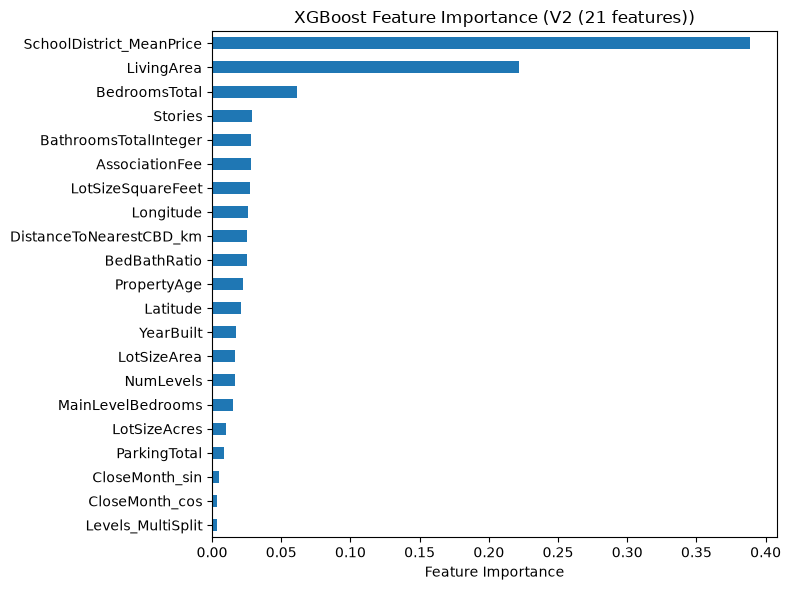

In [15]:
model_lookup = {
    'XGBoost': xgb_final,
    'LightGBM': lgbm_final,
    'Decision Tree (tuned)': dt_final,
    'Random Forest (tuned)': rf_final,
}

winner_name = final_comparison.iloc[0]['Model']
winner_model = model_lookup.get(winner_name)

if winner_model is not None:
    importances = pd.Series(winner_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    print(importances)

    plt.figure(figsize=(8, 6))
    importances.plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title(f'{winner_name} Feature Importance ({FEATURE_SET_NAME})')
    plt.tight_layout()
    plt.show()
else:
    print(f"Winner is '{winner_name}', a fixed-hyperparameter baseline from step 1 (Linear "
          f"Regression or an untuned Decision Tree/Random Forest) rather than one of the models "
          f"refit above — no feature-importance plot to show here, but see the Notes below.")


## Ideas for Further Models to Try

- **CatBoost** — handles high-cardinality categoricals (e.g. `SchoolDistrict`, `City`) natively
  via ordered target statistics, which could let us skip some of the manual target-encoding done
  in `02_preprocessing.ipynb`/`05_feature_engineering.ipynb` and its associated leakage-guarding
  logic, while still getting a gradient-boosted model in the mix.
- **`sklearn.ensemble.HistGradientBoostingRegressor`** — a no-extra-dependency GBM with native
  missing-value handling (relevant given the missingness patterns already documented for lot size
  and other fields) and monotonic-constraint support, which is attractive for an AVM: e.g.
  constraining price to be non-decreasing in `LivingArea` can prevent implausible extrapolation
  in sparse regions of feature space.
- **Stacking/blending** (RF + XGBoost + LightGBM, or a simple average) — the three tree-based
  models likely make correlated but not identical errors; a stacked ensemble is a cheap way to
  test whether that residual disagreement is exploitable before investing in a heavier single
  model.
- **Quantile regression (LightGBM `objective='quantile'` or `GradientBoostingRegressor`)** — an
  AVM arguably needs a price *range*, not just a point estimate, for it to be usable in an
  offer/pricing workflow; predicting the 10th/50th/90th percentile directly would give calibrated
  uncertainty bands instead of relying on a single global error metric.
- **Regularized linear model with interactions (Ridge/ElasticNet + polynomial or explicit
  feature-cross terms)** — a stronger, still-interpretable baseline than plain `LinearRegression`,
  useful for isolating how much of the gradient-boosting gain is "nonlinearity" the linear model
  simply can't express vs. genuine higher-order interaction effects.
- Before calling any of the above production-ready: run the **rolling-origin backtest** required
  by the best-practices doc (2-3 additional historical cutoffs) on whichever model wins here — a
  single 2025-06 test month isn't enough to rule out overfitting to one market moment.